In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Backtest — Country Rotation (Full)

Long-term portfolio research: country-rotation strategies, monthly + annual rebal.

**Universe (23 countries via iShares ETFs):**
- Developed (13): EWJ EWG EWU EWA EWC EWI EWP EWQ EWL EWD EWN EWS EWH
- Emerging (10): EWZ EWW EWY EWT MCHI INDA EZA EPOL TUR EIDO
- Blocs (Family 4 only): EFA EEM
- Benchmark: SPY (excluded from rotation universe)
- Cash: BIL

**Strategies (18 total):**

*Monthly rebal:*
- Family 1 — Cross-sectional momentum (5): 12-1 top5, 6-1 top5, 3-1 top5, 12-1 top3, 12-1 LS5x5
- Family 2 — Time-series momentum (3): 12mo positive, SMA200, SMA10mo Faber
- Family 3 — Dual momentum (3): Antonacci top 1/3/5
- Family 4 — EM vs DM (2): pure, with BIL filter

*Annual rolling 12-month rebal (5):*
- Annual 12-mo momentum top 5 EW
- Annual 12-mo momentum top 3 EW
- Annual TS momentum (Faber)
- Annual dual momentum top 1
- Annual contrarian 3yr bottom 5 ⚠️ ~6 yr OOS
- Annual contrarian 5yr bottom 5 ⚠️ ~4 yr OOS

**Conventions:**
- Zero slippage (signal comparison)
- Monthly or rolling-12mo rebal
- Min history required before country joins universe (no look-ahead)
- Canonical: SPY-filled returns; headline = ΔCAGR vs SPY

## Section 0 — Setup

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from _shared.loaders_data import fetch_historical_data

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

OUT_DIR = Path("./output")
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / "daily_equity").mkdir(exist_ok=True)
(OUT_DIR / "trades").mkdir(exist_ok=True)

COUNTRIES_DM = ["EWJ", "EWG", "EWU", "EWA", "EWC", "EWI", "EWP", "EWQ", "EWL", "EWD", "EWN", "EWS", "EWH"]
COUNTRIES_EM = ["EWZ", "EWW", "EWY", "EWT", "MCHI", "INDA", "EZA", "EPOL", "TUR", "EIDO"]
COUNTRIES = COUNTRIES_DM + COUNTRIES_EM
BLOCS = ["EFA", "EEM"]
OTHER = ["SPY", "BIL"]
TICKERS_ALL = COUNTRIES + BLOCS + OTHER

START = datetime(2003, 1, 1)
END = datetime(2025, 5, 1)

print(f"Universe: {len(COUNTRIES)} countries ({len(COUNTRIES_DM)} DM + {len(COUNTRIES_EM)} EM)")
print(f"Total tickers: {len(TICKERS_ALL)}")

Universe: 23 countries (13 DM + 10 EM)
Total tickers: 27


## Section 1 — Data pull & validation

In [2]:
raw = fetch_historical_data(TICKERS_ALL, TimeFrame(1, TimeFrameUnit.Day), START, END)

data = {}
for tk, df in raw.items():
    df = df.copy()
    df.index = df.index.tz_localize(None) if df.index.tz is not None else df.index
    data[tk] = df

print("Date ranges:")
for tk in TICKERS_ALL:
    if tk in data:
        df = data[tk]
        print(f"  {tk:5s}: {df.index.min().date()} → {df.index.max().date()}  ({len(df)} bars)")
    else:
        print(f"  {tk:5s}: NOT RETURNED")

Fetching EWJ...
  2,345 bars
Fetching EWG...
  2,345 bars
Fetching EWU...
  2,345 bars
Fetching EWA...
  2,345 bars
Fetching EWC...
  2,345 bars
Fetching EWI...
  2,345 bars
Fetching EWP...
  2,345 bars
Fetching EWQ...
  2,345 bars
Fetching EWL...
  2,345 bars
Fetching EWD...
  2,345 bars
Fetching EWN...
  2,345 bars
Fetching EWS...
  2,345 bars
Fetching EWH...
  2,345 bars
Fetching EWZ...
  2,345 bars
Fetching EWW...
  2,345 bars
Fetching EWY...
  2,345 bars
Fetching EWT...
  2,345 bars
Fetching MCHI...
  2,345 bars
Fetching INDA...
  2,345 bars
Fetching EZA...
  2,345 bars
Fetching EPOL...
  2,345 bars
Fetching TUR...
  2,345 bars
Fetching EIDO...
  2,345 bars
Fetching EFA...
  2,345 bars
Fetching EEM...
  2,345 bars
Fetching SPY...
  2,345 bars
Fetching BIL...
  2,345 bars
Date ranges:
  EWJ  : 2016-01-04 → 2025-04-30  (2345 bars)
  EWG  : 2016-01-04 → 2025-04-30  (2345 bars)
  EWU  : 2016-01-04 → 2025-04-30  (2345 bars)
  EWA  : 2016-01-04 → 2025-04-30  (2345 bars)
  EWC  : 2016-01

In [3]:
# Unified price frame on business-day grid
bdays = pd.bdate_range(START, END)
px = pd.DataFrame(index=bdays)
for tk, df in data.items():
    s = df["close"].copy()
    s.index = s.index.normalize()
    px[tk] = s.reindex(bdays).ffill(limit=3)

first_valid = px["SPY"].first_valid_index()
px = px.loc[first_valid:]
rets = px.pct_change()

print(f"Unified price frame: {px.index.min().date()} → {px.index.max().date()}  shape={px.shape}")

# Availability snapshot
avail_rows = []
for tk in TICKERS_ALL:
    fv = px[tk].first_valid_index()
    n_valid = px[tk].notna().sum()
    avail_rows.append({"ticker": tk, "first_valid": fv.date() if fv is not None else None,
                       "n_valid": n_valid, "pct_avail": 100 * n_valid / len(px)})
print("\nAvailability:")
print(pd.DataFrame(avail_rows).set_index("ticker").to_string())

Unified price frame: 2016-01-04 → 2025-05-01  shape=(2434, 27)

Availability:
       first_valid  n_valid  pct_avail
ticker                                
EWJ     2016-01-04     2434      100.0
EWG     2016-01-04     2434      100.0
EWU     2016-01-04     2434      100.0
EWA     2016-01-04     2434      100.0
EWC     2016-01-04     2434      100.0
EWI     2016-01-04     2434      100.0
EWP     2016-01-04     2434      100.0
EWQ     2016-01-04     2434      100.0
EWL     2016-01-04     2434      100.0
EWD     2016-01-04     2434      100.0
EWN     2016-01-04     2434      100.0
EWS     2016-01-04     2434      100.0
EWH     2016-01-04     2434      100.0
EWZ     2016-01-04     2434      100.0
EWW     2016-01-04     2434      100.0
EWY     2016-01-04     2434      100.0
EWT     2016-01-04     2434      100.0
MCHI    2016-01-04     2434      100.0
INDA    2016-01-04     2434      100.0
EZA     2016-01-04     2434      100.0
EPOL    2016-01-04     2434      100.0
TUR     2016-01-04     24

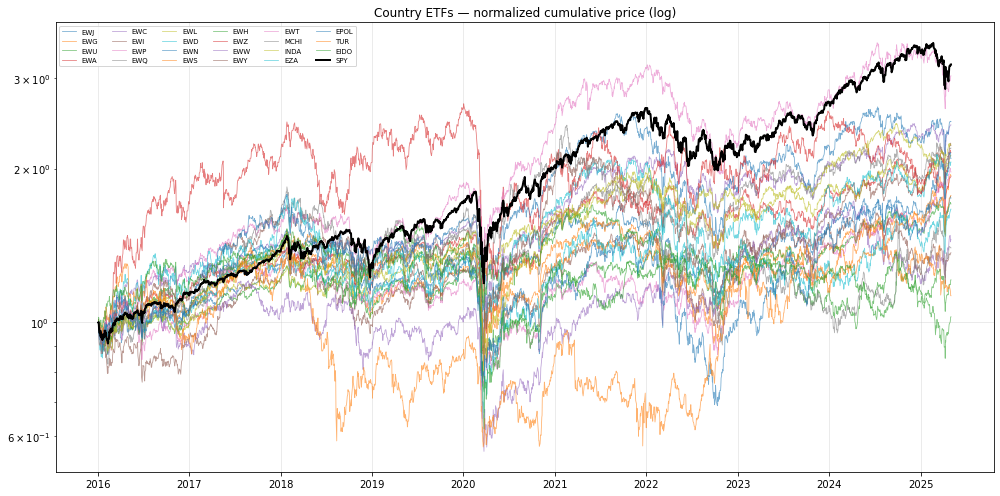

In [4]:
# Sanity plot
fig, ax = plt.subplots(figsize=(14, 7))
for tk in COUNTRIES:
    s = px[tk].dropna()
    if len(s) == 0: continue
    norm = s / s.iloc[0]
    ax.plot(np.asarray(norm.index), np.asarray(norm.values), lw=0.8, alpha=0.6, label=tk)
spy_norm = px["SPY"] / px["SPY"].iloc[0]
ax.plot(np.asarray(spy_norm.index), np.asarray(spy_norm.values), lw=2, color="black", label="SPY")
ax.set_yscale("log")
ax.set_title("Country ETFs — normalized cumulative price (log)")
ax.legend(ncol=6, fontsize=7, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Section 2 — Helpers

In [5]:
SLIPPAGE_BPS = 0

def metrics_from_returns(daily_ret, name=""):
    r = daily_ret.dropna()
    if len(r) < 2 or r.std() == 0:
        return {"name": name, "sharpe": 0, "cagr": 0, "vol": 0, "max_dd": 0, "calmar": 0, "n_days": len(r)}
    eq = (1 + r).cumprod()
    years = len(r) / 252
    cagr = eq.iloc[-1] ** (1/years) - 1
    vol = r.std() * np.sqrt(252)
    sharpe = r.mean() / r.std() * np.sqrt(252)
    dd = (eq / eq.cummax() - 1).min()
    calmar = cagr / abs(dd) if dd < 0 else np.nan
    return {"name": name, "sharpe": sharpe, "cagr": cagr, "vol": vol, "max_dd": dd, "calmar": calmar, "n_days": len(r)}

def bootstrap_sharpe_pvalue(daily_ret, n_iter=1000, seed=42):
    r = daily_ret.dropna().values
    if len(r) < 30 or r.std() == 0:
        return np.nan
    rng = np.random.RandomState(seed)
    sharpes = np.empty(n_iter)
    for i in range(n_iter):
        sample = rng.choice(r, size=len(r), replace=True)
        sharpes[i] = sample.mean() / sample.std() * np.sqrt(252) if sample.std() > 0 else 0
    return (sharpes <= 0).mean()

def positions_to_returns(weights, returns, slippage_bps=SLIPPAGE_BPS):
    w = weights.shift(1).fillna(0)
    gross = (w * returns).sum(axis=1)
    if slippage_bps > 0:
        turnover = (weights - weights.shift(1)).abs().sum(axis=1).fillna(0)
        cost = turnover * (slippage_bps / 10000)
        return gross - cost
    return gross

def evaluate(name, weights):
    """Evaluate: SPY-fill on idle days for like-for-like vs SPY."""
    strat_ret = positions_to_returns(weights, rets[weights.columns].fillna(0))
    active_today = (weights.abs().sum(axis=1) > 0)
    active_yesterday = active_today.shift(1).fillna(False)
    
    filled_ret = strat_ret.where(active_yesterday, rets["SPY"])
    active_only_ret = strat_ret.where(active_yesterday)
    
    m_filled = metrics_from_returns(filled_ret, f"{name}_filled")
    m_active = metrics_from_returns(active_only_ret, f"{name}_active")
    p_filled = bootstrap_sharpe_pvalue(filled_ret)
    
    eq_filled = (1 + filled_ret.fillna(0)).cumprod()
    eq_filled.to_frame("equity").to_csv(OUT_DIR / "daily_equity" / f"{name}.csv")
    
    return {"name": name, "active_days": int(active_today.sum()), "pct_active": active_today.mean() * 100,
            "active": m_active, "filled": m_filled, "p_filled": p_filled,
            "strat_ret": strat_ret, "filled_ret": filled_ret, "eq_filled": eq_filled, "weights": weights}

def print_eval(r, spy_cagr):
    delta = r["filled"]["cagr"] - spy_cagr
    flag = "✅" if delta > 0 else "❌"
    print(f"  Active: {r['active_days']:>4} ({r['pct_active']:.0f}%)  |  "
          f"Sharpe {r['filled']['sharpe']:>5.2f}  CAGR {r['filled']['cagr']:>6.1%}  "
          f"MaxDD {r['filled']['max_dd']:>6.1%}  ΔCAGR {flag} {delta:+.1%}  p={r['p_filled']:.3f}")

spy_ret_full = rets["SPY"]
spy_eq_full = (1 + spy_ret_full.fillna(0)).cumprod()
spy_metrics = metrics_from_returns(spy_ret_full, "SPY_BH")
SPY_CAGR = spy_metrics["cagr"]
print(f"SPY benchmark: Sharpe {spy_metrics['sharpe']:.2f} | CAGR {SPY_CAGR:.1%} | MaxDD {spy_metrics['max_dd']:.1%}")

SPY benchmark: Sharpe 0.77 | CAGR 12.8% | MaxDD -33.8%


## Section 3 — Signal builders

In [6]:
def monthly_close_panel(prices):
    return prices.resample("BM").last()

def n_minus_1_momentum(prices, n_months):
    """Score at T uses prices [T-N-1, T-1] (skip last month)."""
    monthly = monthly_close_panel(prices)
    return (monthly.shift(1) / monthly.shift(n_months + 1)) - 1

def simple_momentum(prices, n_months):
    """Plain N-month momentum without skip-1."""
    monthly = monthly_close_panel(prices)
    return (monthly / monthly.shift(n_months)) - 1

def available_mask(prices, n_months_required):
    monthly = monthly_close_panel(prices)
    return monthly.shift(n_months_required + 1).notna()

def weights_from_monthly_picks(picks_monthly, daily_index, equal_weight=True):
    """Monthly picks → daily weights (1 month hold)."""
    w_daily = pd.DataFrame(0.0, index=daily_index, columns=picks_monthly.columns)
    for i, month_end in enumerate(picks_monthly.index):
        picks = picks_monthly.iloc[i]
        if picks.sum() == 0: continue
        next_start = month_end + pd.offsets.BDay(1)
        next_end = picks_monthly.index[i+1] if i+1 < len(picks_monthly.index) else daily_index[-1]
        mask = (daily_index >= next_start) & (daily_index <= next_end)
        if equal_weight:
            weight = 1.0 / picks.sum()
            for c in picks_monthly.columns:
                if picks[c] == 1:
                    w_daily.loc[mask, c] = weight
    return w_daily

def lift_monthly_to_daily(monthly_w, daily_index):
    """Lift continuous monthly weights to daily (1 month hold)."""
    w_daily = pd.DataFrame(0.0, index=daily_index, columns=monthly_w.columns)
    for i, month_end in enumerate(monthly_w.index):
        next_start = month_end + pd.offsets.BDay(1)
        next_end = monthly_w.index[i+1] if i+1 < len(monthly_w.index) else daily_index[-1]
        mask = (daily_index >= next_start) & (daily_index <= next_end)
        for c in monthly_w.columns:
            w_daily.loc[mask, c] = monthly_w.iloc[i][c]
    return w_daily

def overlapping_12mo_weights(monthly_cohort_weights, daily_index):
    """Rolling 12-month: each day's portfolio = avg of last 12 monthly cohorts."""
    cols = list(monthly_cohort_weights.columns)
    w_daily = pd.DataFrame(0.0, index=daily_index, columns=cols)
    cohort_dates = monthly_cohort_weights.index
    
    for i, dt in enumerate(daily_index):
        relevant = cohort_dates[(cohort_dates < dt) & (cohort_dates >= dt - pd.DateOffset(months=12))]
        if len(relevant) == 0: continue
        avg_w = monthly_cohort_weights.loc[relevant].mean(axis=0)
        w_daily.loc[dt] = avg_w.values
    return w_daily

print("Signal builders loaded.")

Signal builders loaded.


## Section 4 — Family 1: Cross-sectional momentum (monthly)

In [7]:
results = {}

def xsec_momentum(prices, n_months, top_k):
    """Long-only top-K cross-sectional momentum."""
    mom = n_minus_1_momentum(prices[COUNTRIES], n_months)
    avail = available_mask(prices[COUNTRIES], n_months)
    mom_masked = mom.where(avail)
    picks = pd.DataFrame(0, index=mom_masked.index, columns=mom_masked.columns)
    for i, dt in enumerate(mom_masked.index):
        row = mom_masked.iloc[i].dropna()
        if len(row) < top_k: continue
        picks.loc[dt, row.nlargest(top_k).index] = 1
    return picks

def xsec_long_short(prices, n_months, top_k, bottom_k):
    mom = n_minus_1_momentum(prices[COUNTRIES], n_months)
    avail = available_mask(prices[COUNTRIES], n_months)
    mom_masked = mom.where(avail)
    w_monthly = pd.DataFrame(0.0, index=mom_masked.index, columns=mom_masked.columns)
    for i, dt in enumerate(mom_masked.index):
        row = mom_masked.iloc[i].dropna()
        if len(row) < top_k + bottom_k: continue
        w_monthly.loc[dt, row.nlargest(top_k).index] = 0.5 / top_k
        w_monthly.loc[dt, row.nsmallest(bottom_k).index] = -0.5 / bottom_k
    return w_monthly

# 1a-1e
for name, n_months, top_k in [("xsec_mom_12-1_top5", 12, 5),
                                ("xsec_mom_6-1_top5", 6, 5),
                                ("xsec_mom_3-1_top5", 3, 5),
                                ("xsec_mom_12-1_top3", 12, 3)]:
    picks = xsec_momentum(px, n_months=n_months, top_k=top_k)
    w = weights_from_monthly_picks(picks, px.index)
    print(f"=== {name} ===")
    r = evaluate(name, w); print_eval(r, SPY_CAGR); results[name] = r

# 1e Long-short
w_ls = xsec_long_short(px, n_months=12, top_k=5, bottom_k=5)
w_ls_daily = lift_monthly_to_daily(w_ls, px.index)
print("=== xsec_mom_12-1_LS5x5 ===")
r = evaluate("xsec_mom_12-1_LS5x5", w_ls_daily); print_eval(r, SPY_CAGR); results["xsec_mom_12-1_LS5x5"] = r

=== xsec_mom_12-1_top5 ===
  Active: 2132 (88%)  |  Sharpe  0.47  CAGR   7.0%  MaxDD -44.3%  ΔCAGR ❌ -5.8%  p=0.081
=== xsec_mom_6-1_top5 ===
  Active: 2261 (93%)  |  Sharpe  0.46  CAGR   7.1%  MaxDD -47.5%  ΔCAGR ❌ -5.7%  p=0.072
=== xsec_mom_3-1_top5 ===
  Active: 2327 (96%)  |  Sharpe  0.25  CAGR   3.0%  MaxDD -49.7%  ΔCAGR ❌ -9.8%  p=0.215
=== xsec_mom_12-1_top3 ===
  Active: 2132 (88%)  |  Sharpe  0.41  CAGR   6.1%  MaxDD -40.4%  ΔCAGR ❌ -6.7%  p=0.099
=== xsec_mom_12-1_LS5x5 ===
  Active: 2132 (88%)  |  Sharpe  0.02  CAGR  -0.1%  MaxDD -21.7%  ΔCAGR ❌ -12.9%  p=0.470


## Section 5 — Family 2: Time-series momentum (monthly)

In [8]:
def ts_momentum_12mo(prices):
    """Hold country if 12mo return > 0."""
    mom = simple_momentum(prices[COUNTRIES], n_months=12)
    avail = available_mask(prices[COUNTRIES], n_months_required=12)
    return (mom.where(avail) > 0).astype(int)

def ts_sma_filter(prices, window_days):
    """Daily price > N-day SMA, sampled at month-end."""
    sma = prices[COUNTRIES].rolling(window_days).mean()
    above = (prices[COUNTRIES] > sma).astype(int)
    return above.resample("BM").last()

def ts_sma_monthly(prices, n_months):
    """Monthly price > N-month SMA (Faber)."""
    monthly = monthly_close_panel(prices[COUNTRIES])
    sma = monthly.rolling(n_months).mean()
    return (monthly > sma).astype(int)

def picks_to_weights_with_bil_fill(picks, daily_index):
    cols = list(picks.columns) + ["BIL"]
    w_daily = pd.DataFrame(0.0, index=daily_index, columns=cols)
    for i, month_end in enumerate(picks.index):
        row = picks.iloc[i]
        next_start = month_end + pd.offsets.BDay(1)
        next_end = picks.index[i+1] if i+1 < len(picks.index) else daily_index[-1]
        mask = (daily_index >= next_start) & (daily_index <= next_end)
        n_on = int(row.sum())
        if n_on == 0:
            w_daily.loc[mask, "BIL"] = 1.0
        else:
            weight = 1.0 / n_on
            for c in picks.columns:
                if row[c] == 1:
                    w_daily.loc[mask, c] = weight
    return w_daily

# 2a: 12mo positive
picks_2a = ts_momentum_12mo(px)
w_2a = picks_to_weights_with_bil_fill(picks_2a, px.index)
print("=== ts_mom_12mo_positive ===")
r = evaluate("ts_mom_12mo_positive", w_2a); print_eval(r, SPY_CAGR); results["ts_mom_12mo_positive"] = r

# 2b: SMA200 daily
picks_2b = ts_sma_filter(px, window_days=200)
avail_200 = available_mask(px[COUNTRIES], n_months_required=10)
picks_2b = picks_2b.where(avail_200, 0)
w_2b = picks_to_weights_with_bil_fill(picks_2b, px.index)
print("\n=== ts_sma200_daily ===")
r = evaluate("ts_sma200_daily", w_2b); print_eval(r, SPY_CAGR); results["ts_sma200_daily"] = r

# 2c: SMA10mo Faber
picks_2c = ts_sma_monthly(px, n_months=10)
avail_10mo = available_mask(px[COUNTRIES], n_months_required=10)
picks_2c = picks_2c.where(avail_10mo, 0)
w_2c = picks_to_weights_with_bil_fill(picks_2c, px.index)
print("\n=== ts_sma10mo_faber ===")
r = evaluate("ts_sma10mo_faber", w_2c); print_eval(r, SPY_CAGR); results["ts_sma10mo_faber"] = r

=== ts_mom_12mo_positive ===
  Active: 2414 (99%)  |  Sharpe  0.23  CAGR   2.5%  MaxDD -50.9%  ΔCAGR ❌ -10.3%  p=0.236

=== ts_sma200_daily ===
  Active: 2414 (99%)  |  Sharpe  0.49  CAGR   6.8%  MaxDD -39.4%  ΔCAGR ❌ -6.0%  p=0.067

=== ts_sma10mo_faber ===
  Active: 2414 (99%)  |  Sharpe  0.49  CAGR   6.9%  MaxDD -39.0%  ΔCAGR ❌ -5.8%  p=0.069


## Section 6 — Family 3: Dual momentum (monthly)

In [9]:
def dual_momentum(prices, top_k):
    """Top-K beating BIL, BIL fills empty slots."""
    mom_countries = simple_momentum(prices[COUNTRIES], n_months=12)
    mom_bil = simple_momentum(prices[["BIL"]], n_months=12)
    avail = available_mask(prices[COUNTRIES], n_months_required=12)
    cols = COUNTRIES + ["BIL"]
    out = pd.DataFrame(0.0, index=mom_countries.index, columns=cols)
    
    for i, dt in enumerate(mom_countries.index):
        bil_t = mom_bil.iloc[i, 0] if i < len(mom_bil) else np.nan
        if pd.isna(bil_t): continue
        row = mom_countries.iloc[i].where(avail.iloc[i]).dropna()
        eligible = row[row > bil_t]
        if len(eligible) == 0:
            out.loc[dt, "BIL"] = 1.0
            continue
        n_picks = min(top_k, len(eligible))
        weight_each = 1.0 / top_k
        for c in eligible.nlargest(n_picks).index:
            out.loc[dt, c] = weight_each
        empty_slots = top_k - n_picks
        if empty_slots > 0:
            out.loc[dt, "BIL"] = empty_slots * weight_each
    return out

for top_k in [1, 3, 5]:
    w_m = dual_momentum(px, top_k=top_k)
    w = lift_monthly_to_daily(w_m, px.index)
    name = f"dual_mom_top{top_k}"
    print(f"=== {name} ===")
    r = evaluate(name, w); print_eval(r, SPY_CAGR); results[name] = r

=== dual_mom_top1 ===
  Active: 2152 (88%)  |  Sharpe  0.37  CAGR   6.3%  MaxDD -41.7%  ΔCAGR ❌ -6.5%  p=0.123
=== dual_mom_top3 ===
  Active: 2152 (88%)  |  Sharpe  0.26  CAGR   3.1%  MaxDD -47.0%  ΔCAGR ❌ -9.7%  p=0.202
=== dual_mom_top5 ===
  Active: 2152 (88%)  |  Sharpe  0.25  CAGR   2.9%  MaxDD -48.8%  ΔCAGR ❌ -9.9%  p=0.218


## Section 7 — Family 4: EM vs DM rotation (monthly)

In [10]:
def em_vs_dm(prices, with_bil_filter=False):
    mom = simple_momentum(prices[["EEM", "EFA", "BIL"]], n_months=12)
    avail = mom["EEM"].notna() & mom["EFA"].notna()
    cols = ["EEM", "EFA", "BIL"]
    out = pd.DataFrame(0.0, index=mom.index, columns=cols)
    
    for i, dt in enumerate(mom.index):
        if not avail.iloc[i]: continue
        eem_r, efa_r = mom["EEM"].iloc[i], mom["EFA"].iloc[i]
        bil_r = mom["BIL"].iloc[i] if not pd.isna(mom["BIL"].iloc[i]) else 0
        winner = "EEM" if eem_r > efa_r else "EFA"
        if with_bil_filter and max(eem_r, efa_r) < bil_r:
            out.loc[dt, "BIL"] = 1.0
        else:
            out.loc[dt, winner] = 1.0
    return out

for name, fltr in [("em_dm_rotation", False), ("em_dm_rotation_bilfilter", True)]:
    w_m = em_vs_dm(px, with_bil_filter=fltr)
    w = lift_monthly_to_daily(w_m, px.index)
    print(f"=== {name} ===")
    r = evaluate(name, w); print_eval(r, SPY_CAGR); results[name] = r

=== em_dm_rotation ===
  Active: 2152 (88%)  |  Sharpe  0.43  CAGR   6.3%  MaxDD -41.0%  ΔCAGR ❌ -6.5%  p=0.093
=== em_dm_rotation_bilfilter ===
  Active: 2152 (88%)  |  Sharpe  0.39  CAGR   4.4%  MaxDD -26.2%  ΔCAGR ❌ -8.4%  p=0.110


## Section 8 — Annual rolling-12-month rebal

Each day's portfolio = average of last 12 monthly cohorts (each cohort held for 12 months).

In [11]:
def picks_to_cohort_weights(picks_monthly, universe_cols):
    cohort = pd.DataFrame(0.0, index=picks_monthly.index, columns=universe_cols)
    for i, dt in enumerate(picks_monthly.index):
        row = picks_monthly.iloc[i]
        n = int(row.sum())
        if n == 0: continue
        for c in picks_monthly.columns:
            if row[c] == 1 and c in universe_cols:
                cohort.loc[dt, c] = 1.0 / n
    return cohort

# 8a: Annual 12mo momentum top 5
picks_8a = xsec_momentum(px, n_months=12, top_k=5)
cohort_8a = picks_to_cohort_weights(picks_8a, COUNTRIES)
w_8a = overlapping_12mo_weights(cohort_8a, px.index)
print("=== annual_xsec_mom_12_top5 ===")
r = evaluate("annual_xsec_mom_12_top5", w_8a); print_eval(r, SPY_CAGR); results["annual_xsec_mom_12_top5"] = r

# 8b: Annual 12mo momentum top 3
picks_8b = xsec_momentum(px, n_months=12, top_k=3)
cohort_8b = picks_to_cohort_weights(picks_8b, COUNTRIES)
w_8b = overlapping_12mo_weights(cohort_8b, px.index)
print("\n=== annual_xsec_mom_12_top3 ===")
r = evaluate("annual_xsec_mom_12_top3", w_8b); print_eval(r, SPY_CAGR); results["annual_xsec_mom_12_top3"] = r

=== annual_xsec_mom_12_top5 ===
  Active: 2132 (88%)  |  Sharpe  0.36  CAGR   4.9%  MaxDD -44.8%  ΔCAGR ❌ -7.9%  p=0.132

=== annual_xsec_mom_12_top3 ===
  Active: 2132 (88%)  |  Sharpe  0.32  CAGR   4.4%  MaxDD -43.8%  ΔCAGR ❌ -8.4%  p=0.155


In [12]:
# 8c: Annual TS momentum (Faber-style)
picks_8c = ts_momentum_12mo(px)
cohort_8c = pd.DataFrame(0.0, index=picks_8c.index, columns=COUNTRIES + ["BIL"])
for i, dt in enumerate(picks_8c.index):
    row = picks_8c.iloc[i]
    n_on = int(row.sum())
    if n_on == 0:
        cohort_8c.loc[dt, "BIL"] = 1.0
    else:
        weight = 1.0 / n_on
        for c in picks_8c.columns:
            if row[c] == 1:
                cohort_8c.loc[dt, c] = weight

w_8c = overlapping_12mo_weights(cohort_8c, px.index)
print("=== annual_ts_mom_12mo ===")
r = evaluate("annual_ts_mom_12mo", w_8c); print_eval(r, SPY_CAGR); results["annual_ts_mom_12mo"] = r

# 8d: Annual dual momentum top 1
cohort_8d = dual_momentum(px, top_k=1)
w_8d = overlapping_12mo_weights(cohort_8d, px.index)
print("\n=== annual_dual_mom_top1 ===")
r = evaluate("annual_dual_mom_top1", w_8d); print_eval(r, SPY_CAGR); results["annual_dual_mom_top1"] = r

=== annual_ts_mom_12mo ===
  Active: 2414 (99%)  |  Sharpe  0.28  CAGR   3.3%  MaxDD -42.8%  ΔCAGR ❌ -9.5%  p=0.186

=== annual_dual_mom_top1 ===
  Active: 2152 (88%)  |  Sharpe  0.24  CAGR   3.0%  MaxDD -48.5%  ΔCAGR ❌ -9.8%  p=0.215


### Contrarian (mean reversion) annual variants
**⚠️ Underpowered in this data sample:**
- 3yr contrarian: first valid trade ~Jan 2019 → ~6 yr OOS
- 5yr contrarian: first valid trade ~Jan 2021 → ~4 yr OOS

In [13]:
def xsec_contrarian(prices, n_months, bottom_k):
    """Long bottom-K by N-month return (mean reversion)."""
    mom = simple_momentum(prices[COUNTRIES], n_months)
    avail = available_mask(prices[COUNTRIES], n_months_required=n_months)
    mom_masked = mom.where(avail)
    picks = pd.DataFrame(0, index=mom_masked.index, columns=mom_masked.columns)
    for i, dt in enumerate(mom_masked.index):
        row = mom_masked.iloc[i].dropna()
        if len(row) < bottom_k: continue
        picks.loc[dt, row.nsmallest(bottom_k).index] = 1
    return picks

# 8e: 3yr contrarian, bottom 5
picks_8e = xsec_contrarian(px, n_months=36, bottom_k=5)
cohort_8e = picks_to_cohort_weights(picks_8e, COUNTRIES)
w_8e = overlapping_12mo_weights(cohort_8e, px.index)
print("=== annual_contrarian_3yr_bot5 [⚠️ ~6yr OOS] ===")
r = evaluate("annual_contrarian_3yr_bot5", w_8e); print_eval(r, SPY_CAGR); results["annual_contrarian_3yr_bot5"] = r

# 8f: 5yr contrarian, bottom 5
picks_8f = xsec_contrarian(px, n_months=60, bottom_k=5)
cohort_8f = picks_to_cohort_weights(picks_8f, COUNTRIES)
w_8f = overlapping_12mo_weights(cohort_8f, px.index)
print("\n=== annual_contrarian_5yr_bot5 [⚠️ ~4yr OOS] ===")
r = evaluate("annual_contrarian_5yr_bot5", w_8f); print_eval(r, SPY_CAGR); results["annual_contrarian_5yr_bot5"] = r

=== annual_contrarian_3yr_bot5 [⚠️ ~6yr OOS] ===
  Active: 1610 (66%)  |  Sharpe  0.55  CAGR   9.1%  MaxDD -44.7%  ΔCAGR ❌ -3.7%  p=0.041

=== annual_contrarian_5yr_bot5 [⚠️ ~4yr OOS] ===
  Active: 1089 (45%)  |  Sharpe  0.80  CAGR  13.5%  MaxDD -33.8%  ΔCAGR ✅ +0.7%  p=0.007


## Section 9 — Master comparison

In [14]:
rows = []
for name, r in results.items():
    rows.append({
        "strategy": name,
        "delta_cagr": r["filled"]["cagr"] - SPY_CAGR,
        "cagr": r["filled"]["cagr"],
        "sharpe": r["filled"]["sharpe"],
        "maxdd": r["filled"]["max_dd"],
        "calmar": r["filled"]["calmar"],
        "p_value": r["p_filled"],
        "pct_active": r["pct_active"],
    })
summary = pd.DataFrame(rows).set_index("strategy").sort_values("delta_cagr", ascending=False)
summary.loc["SPY_BH"] = {"delta_cagr": 0, "cagr": SPY_CAGR, "sharpe": spy_metrics["sharpe"],
                          "maxdd": spy_metrics["max_dd"], "calmar": spy_metrics["calmar"],
                          "p_value": np.nan, "pct_active": 100}

disp = summary.copy()
disp["delta_cagr"] = disp["delta_cagr"].map(lambda x: f"{x:+.1%}" if pd.notna(x) else "")
for c in ["cagr", "maxdd"]:
    disp[c] = disp[c].map(lambda x: f"{x:.1%}" if pd.notna(x) else "")
for c in ["sharpe", "calmar"]:
    disp[c] = disp[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
disp["p_value"] = disp["p_value"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")
disp["pct_active"] = disp["pct_active"].map(lambda x: f"{x:.0f}%")

print("=" * 120)
print("COUNTRY ROTATION FULL SUMMARY — sorted by ΔCAGR vs SPY")
print("=" * 120)
print(disp.to_string())

COUNTRY ROTATION FULL SUMMARY — sorted by ΔCAGR vs SPY
                           delta_cagr   cagr sharpe   maxdd calmar p_value pct_active
strategy                                                                             
annual_contrarian_5yr_bot5      +0.7%  13.5%   0.80  -33.8%   0.40   0.007        45%
annual_contrarian_3yr_bot5      -3.7%   9.1%   0.55  -44.7%   0.20   0.041        66%
xsec_mom_6-1_top5               -5.7%   7.1%   0.46  -47.5%   0.15   0.072        93%
xsec_mom_12-1_top5              -5.8%   7.0%   0.47  -44.3%   0.16   0.081        88%
ts_sma10mo_faber                -5.8%   6.9%   0.49  -39.0%   0.18   0.069        99%
ts_sma200_daily                 -6.0%   6.8%   0.49  -39.4%   0.17   0.067        99%
em_dm_rotation                  -6.5%   6.3%   0.43  -41.0%   0.15   0.093        88%
dual_mom_top1                   -6.5%   6.3%   0.37  -41.7%   0.15   0.123        88%
xsec_mom_12-1_top3              -6.7%   6.1%   0.41  -40.4%   0.15   0.099        88%

In [15]:
# Regime conditioning
covid_window = (px.index >= "2020-02-15") & (px.index <= "2020-08-31")
bear_2022 = (px.index >= "2022-01-01") & (px.index <= "2022-12-31")

def cagr_subperiod(daily_ret, mask):
    r = daily_ret[~mask].dropna()
    if len(r) < 30: return np.nan
    eq = (1 + r).cumprod()
    return eq.iloc[-1] ** (252/len(r)) - 1

rows_r = []
for name, r in results.items():
    fr = r["filled_ret"]
    rows_r.append({
        "strategy": name,
        "cagr_full": r["filled"]["cagr"],
        "cagr_ex_covid": cagr_subperiod(fr, covid_window),
        "cagr_ex_2022": cagr_subperiod(fr, bear_2022),
        "cagr_ex_both": cagr_subperiod(fr, covid_window | bear_2022),
    })
regime_df = pd.DataFrame(rows_r).set_index("strategy").sort_values("cagr_full", ascending=False)
regime_df.loc["SPY_BH"] = {
    "cagr_full": SPY_CAGR,
    "cagr_ex_covid": cagr_subperiod(spy_ret_full, covid_window),
    "cagr_ex_2022": cagr_subperiod(spy_ret_full, bear_2022),
    "cagr_ex_both": cagr_subperiod(spy_ret_full, covid_window | bear_2022),
}

disp_r = regime_df.copy()
for c in disp_r.columns:
    disp_r[c] = disp_r[c].map(lambda x: f"{x:.1%}" if pd.notna(x) else "")
print("=" * 90)
print("REGIME-CONDITIONAL CAGR")
print("=" * 90)
print(disp_r.to_string())

REGIME-CONDITIONAL CAGR
                           cagr_full cagr_ex_covid cagr_ex_2022 cagr_ex_both
strategy                                                                    
annual_contrarian_5yr_bot5     13.5%         13.8%        12.8%        13.1%
annual_contrarian_3yr_bot5      9.1%         12.1%         9.0%        12.4%
xsec_mom_6-1_top5               7.1%          8.3%         8.3%         9.7%
xsec_mom_12-1_top5              7.0%          7.5%         9.2%        10.0%
ts_sma10mo_faber                6.9%          8.3%         7.0%         8.6%
ts_sma200_daily                 6.8%          7.8%         7.1%         8.3%
em_dm_rotation                  6.3%          6.9%         9.1%         9.9%
dual_mom_top1                   6.3%          6.8%         4.5%         5.0%
xsec_mom_12-1_top3              6.1%          5.8%         8.3%         8.1%
annual_xsec_mom_12_top5         4.9%          6.0%         8.0%         9.5%
em_dm_rotation_bilfilter        4.4%          5.5%  

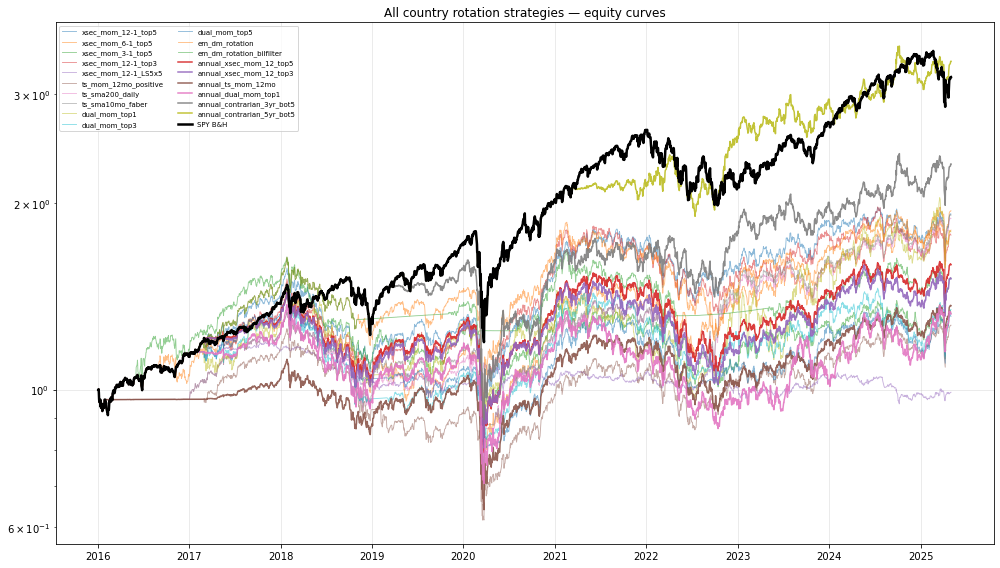

In [16]:
# Equity curves
fig, ax = plt.subplots(figsize=(14, 8))
for name, r in results.items():
    eq = r["eq_filled"]
    style = "-" if name.startswith("annual_") else "-"
    lw = 1.5 if name.startswith("annual_") else 0.9
    alpha = 0.9 if name.startswith("annual_") else 0.5
    ax.plot(np.asarray(eq.index), np.asarray(eq.values), lw=lw, alpha=alpha, label=name)
ax.plot(np.asarray(spy_eq_full.index), np.asarray(spy_eq_full.values), lw=2.5, color="black", label="SPY B&H")
ax.set_yscale("log")
ax.set_title("All country rotation strategies — equity curves")
ax.legend(fontsize=7, ncol=2, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

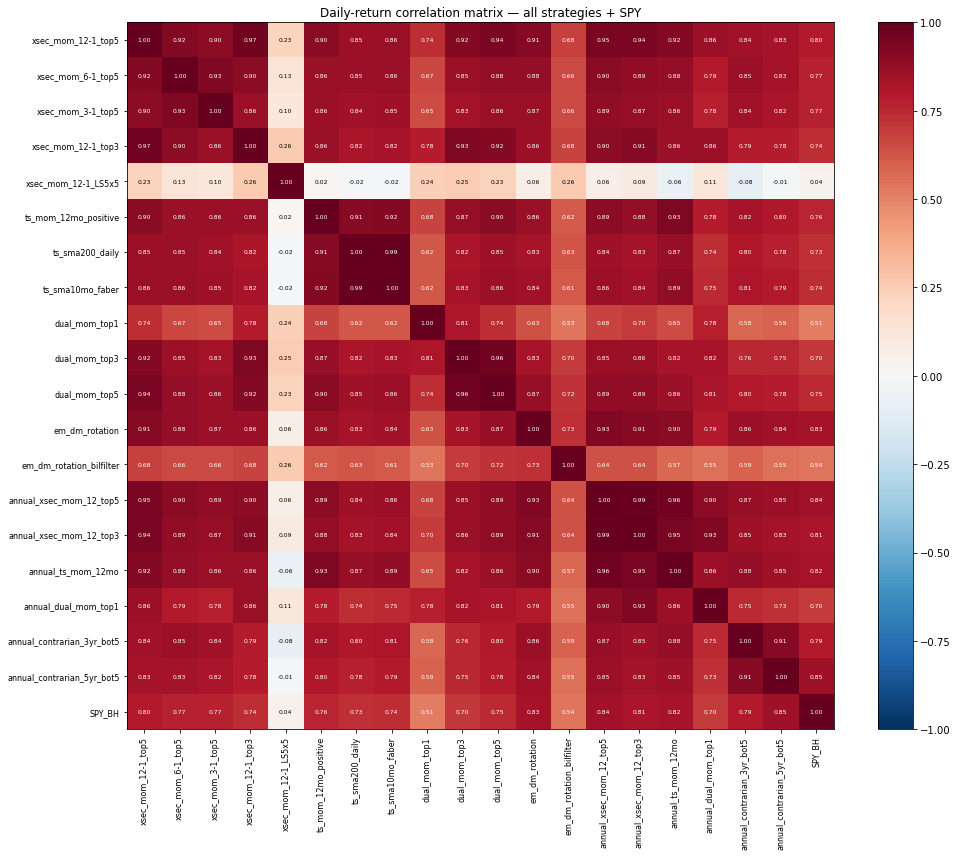


Correlation with SPY (sorted — lowest = best diversifier):
  xsec_mom_12-1_LS5x5                       +0.042
  dual_mom_top1                             +0.514
  em_dm_rotation_bilfilter                  +0.535
  annual_dual_mom_top1                      +0.703
  dual_mom_top3                             +0.704
  ts_sma200_daily                           +0.729
  xsec_mom_12-1_top3                        +0.737
  ts_sma10mo_faber                          +0.741
  dual_mom_top5                             +0.745
  ts_mom_12mo_positive                      +0.761
  xsec_mom_6-1_top5                         +0.768
  xsec_mom_3-1_top5                         +0.770
  annual_contrarian_3yr_bot5                +0.790
  xsec_mom_12-1_top5                        +0.796
  annual_xsec_mom_12_top3                   +0.814
  annual_ts_mom_12mo                        +0.822
  em_dm_rotation                            +0.834
  annual_xsec_mom_12_top5                   +0.841
  annual_contrarian_5y

In [17]:
# Correlation matrix
ret_df = pd.DataFrame({name: r["filled_ret"] for name, r in results.items()})
ret_df["SPY_BH"] = spy_ret_full
corr = ret_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=6,
                color="white" if abs(corr.iloc[i,j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title("Daily-return correlation matrix — all strategies + SPY")
plt.tight_layout(); plt.show()

# Correlations vs SPY sorted (lowest = best diversifier)
spy_corrs = corr["SPY_BH"].drop("SPY_BH").sort_values()
print("\nCorrelation with SPY (sorted — lowest = best diversifier):")
for name, c in spy_corrs.items():
    print(f"  {name:40s}  {c:+.3f}")

In [18]:
# Save
import json
summary.to_csv(OUT_DIR / "country_rotation_summary.csv")
regime_df.to_csv(OUT_DIR / "country_rotation_regime.csv")

out = {}
for name, r in results.items():
    out[name] = {
        "active_days": r["active_days"],
        "pct_active": r["pct_active"],
        "cagr": float(r["filled"]["cagr"]),
        "sharpe": float(r["filled"]["sharpe"]),
        "max_dd": float(r["filled"]["max_dd"]),
        "p_value": float(r["p_filled"]) if pd.notna(r["p_filled"]) else None,
    }
with open(OUT_DIR / "country_rotation_summary.json", "w") as f:
    json.dump(out, f, indent=2)
print(f"Saved → {OUT_DIR}/country_rotation_*.{{csv,json}}")

Saved → output/country_rotation_*.{csv,json}


---

## Findings template (fill after running)

**Best ΔCAGR:**
- _(populate)_

**Best diversifiers (lowest SPY correlation, non-catastrophic CAGR):**
- _(populate)_

**Monthly vs annual comparison:** did annual reduce drawdowns?
- _(populate)_

**Contrarian directional signal:** did 3yr/5yr contrarian look promising despite small sample?
- _(populate)_

**Candidates for Portfolio C (revisit with WRDS long history):**
- _(populate)_